## Environment & Dependencies

**Python 3.x** required. Install all dependencies with:
```
pip install pandas numpy matplotlib scipy scikit-learn statsmodels
```

**Data files** required in the same directory as this notebook:
- `events.csv` — raw Retailrocket clickstream event log (primary dataset)
- `item_properties_part1.csv` / `item_properties_part2.csv` — item attribute tables (used to infer product price)

# Retailrocket E-Commerce Dataset — Purchase Decision Analysis

## 0. 上传并读取数据集

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("events.csv")

## 1. 数据基本信息

In [2]:
print("=== 数据维度 ===")
print(df.shape)

=== 数据维度 ===
(2756101, 5)


In [3]:
print("=== 数据类型 ===")
print(df.dtypes)

=== 数据类型 ===
timestamp          int64
visitorid          int64
event             object
itemid             int64
transactionid    float64
dtype: object


In [4]:
print("=== 非空值计数 ===")
print(df.notnull().sum())

=== 非空值计数 ===
timestamp        2756101
visitorid        2756101
event            2756101
itemid           2756101
transactionid      22457
dtype: int64


In [5]:
print("=== 描述性统计 ===")
df.describe()

=== 描述性统计 ===


,timestamp,visitorid,itemid,transactionid
count,2.756101e+06,2.756101e+06,2.756101e+06,22457.000000
mean,1.436424e+12,7.019229e+05,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,3.507150e+05,13224.000000
max,1.442545e+12,1.407579e+06,4.668670e+05,17671.000000


In [6]:
print("=== 事件类型分布 ===")
df["event"].value_counts()

=== 事件类型分布 ===


event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

## 2. 数据清洗

In [ ]:
# 时间戳转换为日期格式
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

# 筛选出发生过 transaction 的买家及其相关事件
buyers = df[df['event'] == 'transaction']['visitorid'].unique()
buyer_events = df[df['visitorid'].isin(buyers)]

# 构造分析单元（visitorid + itemid），只保留组合内确实发生过 transaction 的商品
# （否则会混入用户只是逛过、没买的商品，导致没有购买时刻，decision_hours 算不出来变成 NaN）
# 用单个客户作为分析单元会磨平同一用户不同购买决策特征的异质性，因此建立的是 visitorid+itemid 组合的分析单元
buyer_events = buyer_events.sort_values('timestamp')
has_purchase = buyer_events.groupby(['visitorid', 'itemid'])['event'].transform(lambda s: (s == 'transaction').any())
purchase_events = buyer_events[has_purchase]
units = purchase_events.groupby(['visitorid', 'itemid'])

print("买家数：", len(buyers))
print("买家相关事件数：", len(buyer_events))
print("分析单元（visitorid+itemid，含购买）数：", units.ngroups)

# 删除 transactionid 列
# 每一笔交易的决策过程已经通过 visitorid+itemid 分析单元聚合，transactionid 信息冗余，故删除
buyer_events = buyer_events.drop(columns=['transactionid'])

# 描述性统计（清洗后）
print(buyer_events.describe())
print(buyer_events['event'].value_counts())

# 保存清洗后的结果
buyer_events.to_csv("events2.csv", index=False)

买家数： 11719
买家相关事件数： 230678
分析单元（visitorid+itemid，含购买）数： 21270
                           timestamp     visitorid         itemid
count                         230678  2.306780e+05  230678.000000
mean   2015-07-07 19:12:24.753529344  6.875363e+05  235667.187881
min       2015-05-03 03:03:20.404000  1.720000e+02      15.000000
25%    2015-06-04 17:35:07.609999872  3.395260e+05  119736.000000
50%    2015-07-07 15:51:38.306000128  6.868540e+05  238386.000000
75%    2015-08-06 19:38:36.672249856  1.030808e+06  351547.500000
max       2015-09-18 02:52:21.219000  1.407398e+06  466864.000000
std                              NaN  3.995951e+05  134887.786350
event
view           180754
addtocart       27467
transaction     22457
Name: count, dtype: int64


## 3. 构造核心变量

In [ ]:
# decision_hours：首次 view 到首次 transaction 的时间差（小时），代表决策时长
# research_views：购买前 view 次数，代表信息搜集程度
# has_addtocart：购买前是否加购（0/1），代表购买行为信号
# view_interval_mean：相邻 view 间隔均值（小时），处理逻辑：
#   research_views == 0 → NaN（无浏览记录，变量无意义）
#   research_views == 1 → 0（单次浏览，间隔为零）
#   research_views >= 2 → 实际计算值（多次浏览的平均间隔）
def unit_features(g):
    first_trans = g.loc[g['event'] == 'transaction', 'timestamp'].min()
    pre_views = g.loc[(g['event'] == 'view') & (g['timestamp'] < first_trans), 'timestamp']
    first_view = pre_views.min() if len(pre_views) > 0 else pd.NaT
    decision_hours = (first_trans - first_view).total_seconds() / 3600 if pd.notna(first_view) else np.nan
    research_views = len(pre_views)
    has_addtocart = int((g['event'].eq('addtocart') & (g['timestamp'] < first_trans)).any())

    if research_views == 0:
        view_interval_mean = np.nan
    elif research_views == 1:
        view_interval_mean = 0
    else:
        view_interval_mean = pre_views.diff().dropna().dt.total_seconds().mean() / 3600

    return pd.Series({
        'first_trans': first_trans,
        'decision_hours': decision_hours,
        'research_views': research_views,
        'has_addtocart': has_addtocart,
        'view_interval_mean': view_interval_mean
    })

data = units.apply(unit_features, include_groups=False).reset_index()

# 删除 research_views == 0 的记录
# 有 transaction 却没有购买前 view，只有两种可能：
#   1) 用户要购买至少要在平台内点开一次商品，没记录到 view 属于数据异常（数据缺失）；
#   2) 用户通过外部链接直接购买，信息搜集在平台外完成，进入平台时决策已形成（决策发生在平台外）。
# 无论哪种情况，这批记录的决策路径在本数据集内都不可观测，因此删除。
data = data[data['research_views'] > 0]

# total_purchases / active_days / unique_items_viewed：用"截至这次决策为止"的累积值，
# 不用该 visitor 的全部历史（全部历史会把这次决策之后才发生的事也算进去，
# 是用未来信息描述决策当时的经验状态，属于数据泄漏，详见 Note2 关键局限）

# total_purchases：该 visitor 在这次 first_trans 之前已完成的购买次数（不含这次本身），代表购买经验
trans_times = buyer_events.loc[buyer_events['event'] == 'transaction', ['visitorid', 'timestamp']].sort_values(['visitorid', 'timestamp']).copy()
trans_times['total_purchases'] = trans_times.groupby('visitorid').cumcount()
trans_times = trans_times.drop_duplicates(subset=['visitorid', 'timestamp'])
data = data.merge(trans_times[['visitorid', 'timestamp', 'total_purchases']],
                   left_on=['visitorid', 'first_trans'], right_on=['visitorid', 'timestamp'], how='left')
data = data.drop(columns=['timestamp'])

# active_days：这次 first_trans 减去该 visitor 最早一次事件的时间（终点改成这次决策时点，不用全部历史的最后一次），代表活跃天数
visitor_first_event = buyer_events.groupby('visitorid')['timestamp'].min().rename('visitor_first_event')
data = data.merge(visitor_first_event, on='visitorid', how='left')
data['active_days'] = (data['first_trans'] - data['visitor_first_event']).dt.total_seconds() / 86400
data = data.drop(columns=['visitor_first_event'])

# unique_items_viewed：该 visitor 截至这次决策为止浏览过的独立商品数（含这次决策本身浏览的商品），代表信息搜集广度
view_events = buyer_events.loc[buyer_events['event'] == 'view', ['visitorid', 'itemid', 'timestamp']].sort_values(['visitorid', 'timestamp']).copy()

def running_unique(g):
    seen = set()
    out = []
    for it in g['itemid']:
        seen.add(it)
        out.append(len(seen))
    return pd.Series(out, index=g.index)

view_events['running_unique'] = view_events.groupby('visitorid', group_keys=False).apply(running_unique)

data = data.sort_values('first_trans')
unique_lookup = view_events[['visitorid', 'timestamp', 'running_unique']].sort_values('timestamp')
data = pd.merge_asof(data, unique_lookup, left_on='first_trans', right_on='timestamp',
                      left_by='visitorid', right_by='visitorid', direction='backward')
data = data.rename(columns={'running_unique': 'unique_items_viewed'}).drop(columns=['timestamp'])
data['unique_items_viewed'] = data['unique_items_viewed'].fillna(0).astype(int)

data = data.reset_index(drop=True)
data.head()

# 保存构造核心变量后的结果
data.to_csv("events3.csv", index=False)

C:\Users\dell\AppData\Local\Temp\ipykernel_22864\3582596659.py:69: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  view_events['running_unique'] = view_events.groupby('visitorid', group_keys=False).apply(running_unique)


In [9]:
# view_interval_mean 因结构性零值比例过高（research_views<=1 时被强制设为 0 或 NaN）不纳入主分析，
# 保留于原始构造数据（events3.csv）中供后续子样本分析使用
data4 = data.drop(columns=['view_interval_mean'])
data4.to_csv("events4.csv", index=False)

print("=== 数据维度 ===")
print(data4.shape)

print("=== 非空值计数 ===")
print(data4.notnull().sum())

print("=== 数据类型 ===")
print(data4.dtypes)

print("=== 描述性统计 ===")
data4.describe()

=== 数据维度 ===
(18738, 9)
=== 非空值计数 ===
visitorid              18738
itemid                 18738
first_trans            18738
decision_hours         18738
research_views         18738
has_addtocart          18738
total_purchases        18738
active_days            18738
unique_items_viewed    18738
dtype: int64
=== 数据类型 ===
visitorid                       int64
itemid                          int64
first_trans            datetime64[ns]
decision_hours                float64
research_views                  int64
has_addtocart                   int64
total_purchases                 int64
active_days                   float64
unique_items_viewed             int64
dtype: object
=== 描述性统计 ===


,visitorid,itemid,first_trans,decision_hours,research_views,has_addtocart,total_purchases,active_days,unique_items_viewed
count,1.873800e+04,18738.000000,18738,18738.000000,18738.000000,18738.000000,18738.000000,18738.000000,18738.000000
mean,6.987495e+05,236575.196606,2015-07-08 21:08:36.274203136,24.430733,2.012221,0.909169,21.888996,9.648164,163.361031
min,1.720000e+02,15.000000,2015-05-03 03:27:21.391000,0.003012,1.000000,0.000000,0.000000,0.000125,1.000000
25%,3.455585e+05,120990.000000,2015-06-05 15:58:39.231500032,0.065214,1.000000,1.000000,0.000000,0.009439,1.000000
50%,7.055420e+05,239006.000000,2015-07-08 15:52:31.814500096,0.158011,1.000000,1.000000,0.000000,0.157822,4.000000
75%,1.062192e+06,352718.500000,2015-08-09 02:19:59.696499968,0.732350,2.000000,1.000000,7.000000,9.003925,59.000000
max,1.407110e+06,466861.000000,2015-09-18 02:43:12.017000,3143.499146,114.000000,1.000000,558.000000,135.459702,3801.000000
std,4.042375e+05,135033.753206,NaN,129.829082,2.218374,0.287377,63.979728,20.067456,439.066135


In [ ]:
# 商品价格（price）：从新数据集 item_properties 推断出 property 790很可能代指价格（依据见 Note2 未来工作章节），不能100%确定，故称为"推断价格"，仅供参考
# 按购买时间点做时间感知匹配，把 price/log_price 接到 data4 上
# 注意：price 是商品属性，不是用户决策行为本身的特征，因此不纳入后续聚类（cluster_vars 不包含它），
# 只在第7节回归分析里，用来对比"加入价格 vs 不加入价格"这两个模型；以及聚类完成后观察类别间价格差异
# first_trans 已经在第3节构造好并保留在 data4 里，这里直接复用，不用再从 events2 重算一次

# price.csv：property=790 推断出的价格，已剔除哨兵值；这里再排除 price=0（理解为异常值或赠品，决策路径与正常定价商品不同）
price_df = pd.read_csv('price.csv', parse_dates=['timestamp'])
price_df = price_df[price_df['price'] > 0].sort_values('timestamp')

# 时间感知匹配：用 merge_asof 取每个商品在购买时间点之前最近的一条价格（按 itemid 分组，向后看）
merge_base = data4[['visitorid', 'itemid', 'first_trans']].sort_values('first_trans')

price_matched = pd.merge_asof(
    merge_base,
    price_df,
    left_on='first_trans', right_on='timestamp',
    left_by='itemid', right_by='itemid',
    direction='backward'
)
print(f"匹配到价格的比例：{price_matched['price'].notna().mean():.2%}")

data4 = data4.merge(price_matched[['visitorid', 'itemid', 'price']], on=['visitorid', 'itemid'], how='left')
data4['log_price'] = np.log1p(data4['price'])
print(f"price 缺失比例：{data4['price'].isna().mean():.2%}")
# 缺失比例可以接受，主要是因为部分商品在购买时没有对应的 property 790 价格记录（可能是促销品、外部链接购买等情况），属于推断数据本身的局限性。

匹配到价格的比例：91.30%
price 缺失比例：8.70%


## 4. 描述性统计（原始值）

In [ ]:
# ── 4. 描述性统计（原始值） ──────────────────────────────────

def describe_var(s, name):
    print(f"--- {name} ---")
    print(f"均值: {s.mean():.3f}, 中位数: {s.median():.3f}, 标准差: {s.std():.3f}, "
          f"Q1: {s.quantile(0.25):.3f}, Q3: {s.quantile(0.75):.3f}, 偏态: {s.skew():.3f}")

raw_vars = ['decision_hours', 'research_views', 'total_purchases', 'active_days', 'unique_items_viewed']
skew_raw = {}
for col in raw_vars:
    describe_var(data4[col], col)
    skew_raw[col] = data4[col].skew()

# 识别右偏变量：偏态 > 1 视为明显右偏，说明这些变量的分布有长尾（极端高值），可能需要对数变换或其他处理来改善模型表现。
print("右偏变量（偏态 > 1）：", [c for c, sk in skew_raw.items() if sk > 1])

# has_addtocart 频数和占比
print(data4['has_addtocart'].value_counts())
print(data4['has_addtocart'].value_counts(normalize=True).round(3))

# research_views 分档频数和占比（说明分档合理性：4次以上样本稀疏、长尾）
rv_bins = [0, 1, 3, data4['research_views'].max()]
rv_labels = ['单次浏览(1次)', '少量浏览(2-3次)', '多次浏览(4次以上)']
rv_bin_preview = pd.cut(data4['research_views'], bins=rv_bins, labels=rv_labels, right=True)
print(rv_bin_preview.value_counts())
print(rv_bin_preview.value_counts(normalize=True).round(3))

# view_interval_mean 结构性缺失说明
# research_views=1 时该列被结构性设为 0（只有一次浏览，没有相邻间隔可算），
# 是结构性缺失而非随机缺失，因此不做插补，不纳入主分析
data3 = pd.read_csv("events3.csv")
single_view_count = (data3['research_views'] == 1).sum()
single_view_ratio = (data3['research_views'] == 1).mean()
print(f"research_views=1 的记录数：{single_view_count}，占比：{single_view_ratio:.3f}")

--- decision_hours ---
均值: 24.431, 中位数: 0.158, 标准差: 129.829, Q1: 0.065, Q3: 0.732, 偏态: 9.956
--- research_views ---
均值: 2.012, 中位数: 1.000, 标准差: 2.218, Q1: 1.000, Q3: 2.000, 偏态: 15.969
--- total_purchases ---
均值: 21.889, 中位数: 0.000, 标准差: 63.980, Q1: 0.000, Q3: 7.000, 偏态: 4.693
--- active_days ---
均值: 9.648, 中位数: 0.158, 标准差: 20.067, Q1: 0.009, Q3: 9.004, 偏态: 2.959
--- unique_items_viewed ---
均值: 163.361, 中位数: 4.000, 标准差: 439.066, Q1: 1.000, Q3: 59.000, 偏态: 4.438
右偏变量（偏态 > 1）： ['decision_hours', 'research_views', 'total_purchases', 'active_days', 'unique_items_viewed']
has_addtocart
1    17036
0     1702
Name: count, dtype: int64
has_addtocart
1    0.909
0    0.091
Name: proportion, dtype: float64
research_views
单次浏览(1次)      10238
少量浏览(2-3次)     6348
多次浏览(4次以上)     2152
Name: count, dtype: int64
research_views
单次浏览(1次)      0.546
少量浏览(2-3次)    0.339
多次浏览(4次以上)    0.115
Name: proportion, dtype: float64
research_views=1 的记录数：10238，占比：0.546


## 5. 变量变换

In [ ]:
# ── 5. 变量变换 ──────────────────────────────────────────────

# decision_hours、research_views、total_purchases、active_days、unique_items_viewed → log1p 变换处理右偏，减小极端值影响
# 原始列保留，新增 log_ 前缀列用于聚类和回归
for col in raw_vars:
    data4[f'log_{col}'] = np.log1p(data4[col])

# has_addtocart 是二元变量，不做变换

# research_views → research_views_bin 分档，仅用于描述性统计和报告展示，不用于聚类
data4['research_views_bin'] = pd.cut(data4['research_views'], bins=rv_bins, labels=rv_labels, right=True)

## 6. 描述性统计（变换后）

--- log_decision_hours ---
均值: 0.805, 中位数: 0.147, 标准差: 1.490, 偏态: 2.397
--- log_research_views ---
均值: 0.995, 中位数: 0.693, 标准差: 0.410, 偏态: 1.607
--- log_total_purchases ---
均值: 1.144, 中位数: 0.000, 标准差: 1.732, 偏态: 1.301
--- log_active_days ---
均值: 1.137, 中位数: 0.147, 标准差: 1.449, 偏态: 0.948
--- log_unique_items_viewed ---
均值: 2.582, 中位数: 1.609, 标准差: 2.166, 偏态: 0.964
                         变换前偏态     变换后偏态
decision_hours        9.955957  2.397193
research_views       15.969498  1.606580
total_purchases       4.693006  1.300768
active_days           2.958855  0.947538
unique_items_viewed   4.437923  0.963879


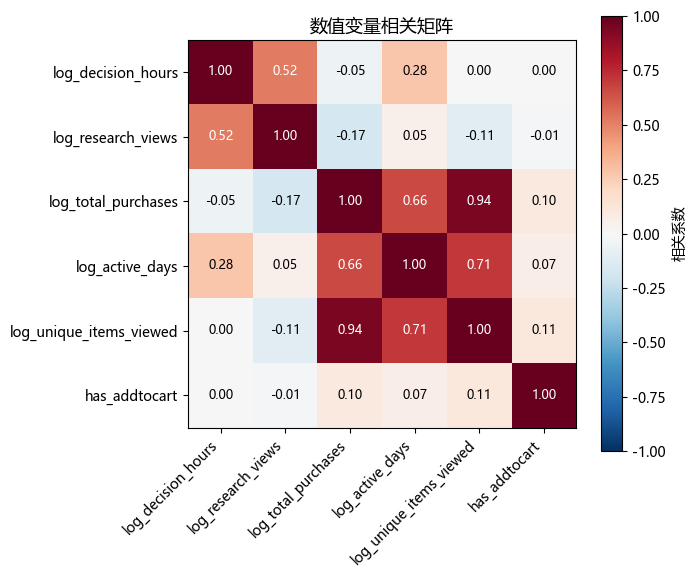

                         log_decision_hours  log_research_views  \
log_decision_hours                    1.000               0.523   
log_research_views                    0.523               1.000   
log_total_purchases                  -0.052              -0.172   
log_active_days                       0.279               0.052   
log_unique_items_viewed               0.004              -0.110   
has_addtocart                         0.002              -0.008   

                         log_total_purchases  log_active_days  \
log_decision_hours                    -0.052            0.279   
log_research_views                    -0.172            0.052   
log_total_purchases                    1.000            0.656   
log_active_days                        0.656            1.000   
log_unique_items_viewed                0.940            0.708   
has_addtocart                          0.096            0.069   

                         log_unique_items_viewed  has_addtocart  
log_deci

In [ ]:
# ── 6. 描述性统计（变换后） ──────────────────────────────────

log_vars = [f'log_{col}' for col in raw_vars]
skew_log = {}
for col in log_vars:
    print(f"--- {col} ---")
    print(f"均值: {data4[col].mean():.3f}, 中位数: {data4[col].median():.3f}, "
          f"标准差: {data4[col].std():.3f}, 偏态: {data4[col].skew():.3f}")
    skew_log[col] = data4[col].skew()

# 对比变换前后偏态，确认改善效果
skew_compare = pd.DataFrame({
    '变换前偏态': skew_raw,
    '变换后偏态': {col.replace('log_', ''): sk for col, sk in skew_log.items()}
})
print(skew_compare)

# 候选聚类变量列表
cluster_vars = ['log_decision_hours', 'log_research_views', 'log_total_purchases',
                'log_active_days', 'log_unique_items_viewed', 'has_addtocart']

# 数值变量两两相关矩阵（热力图）
# 相关矩阵本身是描述数据结构的工具，紧跟描述性统计一起做，而不是等到聚类前才检查共线性
corr_matrix = data4[cluster_vars].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(cluster_vars)))
ax.set_yticks(range(len(cluster_vars)))
ax.set_xticklabels(cluster_vars, rotation=45, ha='right')
ax.set_yticklabels(cluster_vars)

for i in range(len(cluster_vars)):
    for j in range(len(cluster_vars)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color='white' if abs(val) > 0.5 else 'black', fontsize=9)

fig.colorbar(im, ax=ax, label='相关系数')
ax.set_title('数值变量相关矩阵', fontsize=13)
plt.tight_layout()
plt.show()

print(corr_matrix.round(3))

# 发现共线：log_total_purchases 与 log_unique_items_viewed 相关系数高达 0.94
# 这是行为上的必然关联（买得越多，看过的商品种类自然越多），不是变量设计问题，
# 但纳入聚类时会让同一信息被算两次，需要二选一
# 标准一（业务含义）：log_total_purchases 直接反映购买经验，与辅助假设一「经验越丰富，决策越快」直接对应；
#   log_unique_items_viewed 反映探索广度，只是购买经验的间接表现
# 标准二（与其他变量的区分度）：log_total_purchases 与 log_active_days 相关系数 0.656，
#   log_unique_items_viewed 与 log_active_days 相关系数 0.708 更高，说明 unique_items_viewed 的信息
#   已更多被 active_days 覆盖，保留它的边际价值更低
# 结论：删除 log_unique_items_viewed，保留 log_total_purchases
cluster_vars.remove('log_unique_items_viewed')
print("聚类变量（剔除共线后）：", cluster_vars)

## 7. 回归分析（可选）

In [ ]:
# 因变量：log_decision_hours
# Model 1（核心行为变量）：log_research_views、has_addtocart、log_total_purchases、log_active_days
#   不含 log_unique_items_viewed —— 与第六节聚类时一致的处理：它和 log_total_purchases 共线（r=0.94）
# Model 2：Model 1 + log_price（剔除 price 缺失的 8.7% 样本，保证两模型在同一样本上比较的公平）
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.anova import anova_lm

feat1 = ['log_research_views', 'has_addtocart', 'log_total_purchases', 'log_active_days']
feat2 = feat1 + ['log_price']

data_p = data4.dropna(subset=['log_price'])  # Model 2 需要 price，两模型都在这份样本上跑，保证可比

# VIF 检查：确认没有严重多重共线性
vif = pd.Series(
    [variance_inflation_factor(sm.add_constant(data_p[feat1]).values, i) for i in range(len(feat1) + 1)],
    index=['const'] + feat1
)
print("=== VIF（Model 1 特征） ===")
print(vif)

ols1 = sm.OLS(data_p['log_decision_hours'], sm.add_constant(data_p[feat1])).fit()
ols2 = sm.OLS(data_p['log_decision_hours'], sm.add_constant(data_p[feat2])).fit()

print("\n=== Model 1（OLS） ===")
print(ols1.summary())
print("\n=== Model 2（OLS，+price） ===")
print(ols2.summary())

print("\n=== 嵌套模型 F 检验：加入 price 是否显著改善模型 ===")
print(anova_lm(ols1, ols2))

# 几种常见回归方法的预测效果对比（5折交叉验证 R^2，统一用 Model 2 特征集）
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = data_p[feat2].values
y = data_p['log_decision_hours'].values
kf = KFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    'OLS（近似，Ridge alpha趋近0）': make_pipeline(StandardScaler(), Ridge(alpha=1e-4)),
    'Ridge（alpha=1.0）': make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'Lasso（alpha=0.01）': make_pipeline(StandardScaler(), Lasso(alpha=0.01)),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42),
}

print("\n=== 5折交叉验证 R^2（预测效果对比） ===")
for name, model in candidates.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    print(f"{name:28s} R^2 = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Lasso 标准化系数：看 has_addtocart 是否被压缩到 0（单独验证 OLS 里它不显著的结论）
lasso = Lasso(alpha=0.01)
lasso.fit(StandardScaler().fit_transform(X), y)
print("\n=== Lasso 标准化系数 ===")
for f, c in zip(feat2, lasso.coef_):
    print(f"{f:25s} {c:.4f}")
# has_addtocart 的系数被压缩到 0，说明它对 log_decision_hours 的预测贡献不显著，与 OLS 结果一致。

=== VIF（Model 1 特征） ===
const                  17.914923
log_research_views      1.084779
has_addtocart           1.009684
log_total_purchases     1.908792
log_active_days         1.847219
dtype: float64

=== Model 1（OLS） ===
                            OLS Regression Results                            
Dep. Variable:     log_decision_hours   R-squared:                       0.370
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     2506.
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:58:52   Log-Likelihood:                -27314.
No. Observations:               17107   AIC:                         5.464e+04
Df Residuals:                   17102   BIC:                         5.468e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                          

## 8. 四象限 EDA

quadrant
果断型    7273
谨慎型    6404
拖延型    2965
密集型    2096
Name: count, dtype: int64
quadrant
果断型    0.388
谨慎型    0.342
拖延型    0.158
密集型    0.112
Name: proportion, dtype: float64
          decision_hours  research_views  total_purchases  active_days  \
quadrant                                                                 
果断型             0.059516             1.0              1.0     0.264138   
谨慎型             1.304681             3.0              0.0     0.380166   
拖延型             0.356866             1.0              0.0     0.039375   
密集型             0.090323             2.0              0.0     0.122132   

          unique_items_viewed  has_addtocart  
quadrant                                      
果断型                       6.0            1.0  
谨慎型                       4.0            1.0  
拖延型                       3.0            1.0  
密集型                       5.0            1.0  
                    变量          H统计量             p值  显著(p<0.05)
0       decision_hours  14488.69

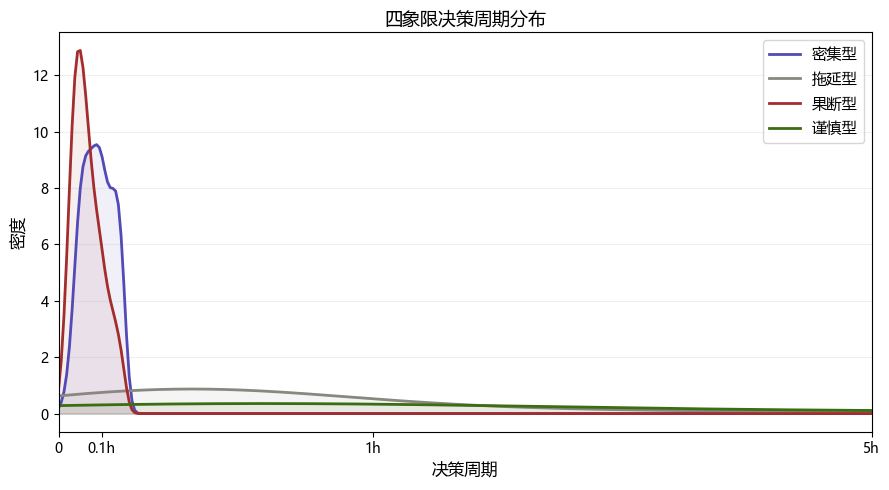

In [ ]:
# 以 research_views 和 decision_hours 中位数为切分点
median_rv = data4['research_views'].median()
median_dh = data4['decision_hours'].median()

# 构造四象限类型变量：果断型（低回看+快决策）/ 谨慎型（高回看+慢决策）/ 拖延型（低回看+慢决策）/ 密集型（高回看+快决策）
# 命名说明：原"冲动型"改为"果断型"——这组决策前购买经验中位数是四象限里最高的（1次），
#   是"凭经验快速拿定主意"而非"没想清楚就乱买"，"冲动"一词预设了负面评价，不准确；
# 原"高效型"改为"密集型"——"效"暗示了决策质量好坏，但本数据集只能测速度和频次，测不出"好不好"，
#   "密集"只描述行为模式本身：回看次数不少（2次）但压缩在很短的时间窗口里完成（0.090h），
#   与谨慎型（回看3次但摊开在1.305h的长窗口里）形成"看的密度高低"这一组干净的对比
low_rv = data4['research_views'] <= median_rv
low_dh = data4['decision_hours'] <= median_dh
data4['quadrant'] = np.select(
    [low_rv & low_dh, ~low_rv & ~low_dh, low_rv & ~low_dh, ~low_rv & low_dh],
    ['果断型', '谨慎型', '拖延型', '密集型'],
    default=''
)
quadrant_order = ['果断型', '谨慎型', '拖延型', '密集型']

# 各象限分布与行为特征描述
quadrant_pct = data4['quadrant'].value_counts(normalize=True).reindex(quadrant_order).round(3)
print(data4['quadrant'].value_counts().reindex(quadrant_order))
print(quadrant_pct)
print(data4.groupby('quadrant')[['decision_hours', 'research_views', 'total_purchases',
                                  'active_days', 'unique_items_viewed', 'has_addtocart']]
      .median().reindex(quadrant_order))

# Kruskal-Wallis 检验：四象限间各变量差异（验证这个分组本身是否有效）
from scipy.stats import kruskal

kw_vars = ['decision_hours', 'research_views', 'total_purchases',
           'active_days', 'unique_items_viewed', 'has_addtocart']

kw_results = []
for col in kw_vars:
    groups = [data4[data4['quadrant'] == q][col] for q in quadrant_order]
    stat, p = kruskal(*groups)
    kw_results.append({'变量': col, 'H统计量': stat, 'p值': p})

kw_df = pd.DataFrame(kw_results)
kw_df['显著(p<0.05)'] = kw_df['p值'] < 0.05
print(kw_df)
# 四象限间各变量差异显著，说明这个分组本身是有效的，即各类决策特征确实存在差异

# 图一：四象限决策周期 KDE 分布（log 轴，刻度还原为原始小时数）
from scipy.stats import gaussian_kde
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(9, 5))
colors = {'果断型': '#A32D2D', '谨慎型': '#3B6D11', '拖延型': '#888780', '密集型': '#534AB7'}
xs = np.linspace(0, np.log1p(5), 300)

for q, grp in data4.groupby('quadrant'):
    kde = gaussian_kde(grp['log_decision_hours'], bw_method=0.3)
    ax.plot(xs, kde(xs), color=colors[q], linewidth=2, label=q)
    ax.fill_between(xs, kde(xs), alpha=0.08, color=colors[q])

# x轴刻度转回原始小时数
tick_vals = [0, np.log1p(0.1), np.log1p(1), np.log1p(5)]
tick_labels = ['0', '0.1h', '1h', '5h']
ax.set_xticks(tick_vals)
ax.set_xticklabels(tick_labels)
ax.set_xlim(0, np.log1p(5))

ax.set_xlabel('决策周期', fontsize=12)
ax.set_ylabel('密度', fontsize=12)
ax.set_title('四象限决策周期分布', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## 9. K-Means 聚类

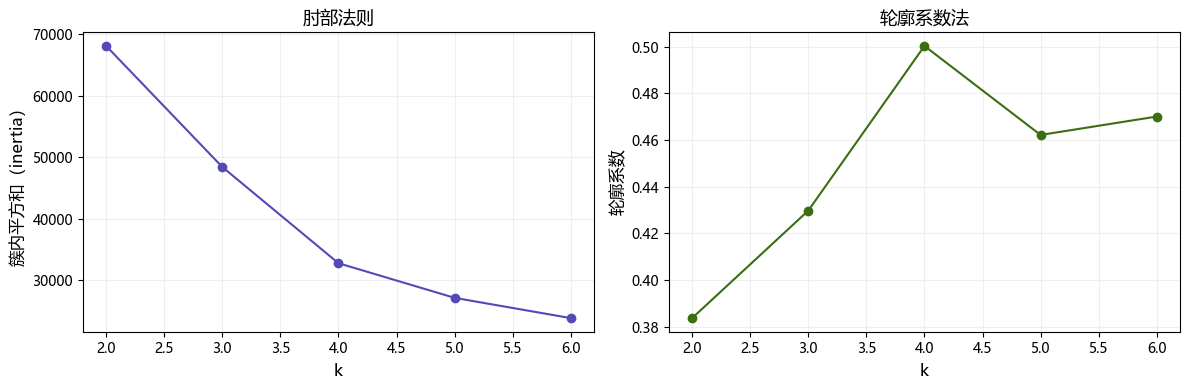

      inertia    轮廓系数
2  68086.2814  0.3837
3  48413.8846  0.4297
4  32772.4210  0.5003
5  27144.1104  0.4621
6  23850.1764  0.4700
最优 k 值：4（轮廓系数 0.5003）
cluster
0     4532
1    10259
2     2320
3     1627
Name: count, dtype: int64
         decision_hours  research_views  total_purchases  active_days  \
cluster                                                                 
0              0.066046             1.0             39.0    18.010581   
1              0.174864             1.0              0.0     0.015060   
2             65.342725             4.0              0.0     7.023913   
3              0.113367             1.0              0.0     0.018042   

         unique_items_viewed  has_addtocart  
cluster                                      
0                      338.5            1.0  
1                        2.0            1.0  
2                        6.0            1.0  
3                        2.0            0.0  


In [16]:
# 标准化处理
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = data4[cluster_vars]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 肘部法则 + 轮廓系数法确定最优 k 值（k=2~6）
inertias = {}
sil_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias[k] = km.inertia_
    sil_scores[k] = silhouette_score(X_scaled, labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(inertias.keys()), list(inertias.values()), marker='o', color='#534AB7')
axes[0].set_xlabel('k', fontsize=12)
axes[0].set_ylabel('簇内平方和（inertia）', fontsize=12)
axes[0].set_title('肘部法则', fontsize=13)
axes[0].grid(alpha=0.2)

axes[1].plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o', color='#3B6D11')
axes[1].set_xlabel('k', fontsize=12)
axes[1].set_ylabel('轮廓系数', fontsize=12)
axes[1].set_title('轮廓系数法', fontsize=13)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(pd.DataFrame({'inertia': inertias, '轮廓系数': sil_scores}).round(4))

best_k = max(sil_scores, key=sil_scores.get)
print(f"最优 k 值：{best_k}（轮廓系数 {sil_scores[best_k]:.4f}）")

# 最优 k 下的聚类结果
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data4['cluster'] = kmeans.fit_predict(X_scaled)

print(data4['cluster'].value_counts().sort_index())

# 各 cluster 行为特征描述
print(data4.groupby('cluster')[['decision_hours', 'research_views', 'total_purchases',
                                 'active_days', 'unique_items_viewed', 'has_addtocart']]
      .median())

## 10. 聚类结果验证

In [ ]:
# Kruskal-Wallis 检验：各 cluster 在 decision_hours 上的差异
from scipy.stats import kruskal

cluster_order = sorted(data4['cluster'].unique())
groups = [data4[data4['cluster'] == c]['decision_hours'] for c in cluster_order]
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis：H={stat:.2f}, p={p:.4g}（显著：{p < 0.05}）")

# 四象限与聚类结果对比
crosstab = pd.crosstab(data4['cluster'], data4['quadrant']).reindex(columns=quadrant_order)
print(crosstab)

# 观察：
# Cluster 2（高摩擦决策）几乎完全落在谨慎型象限内，是两套分组里重合最干净的一组，
#   说明「检索深度+决策周期都偏高」这一类决策，两种方法识别出的是同一批人
# Cluster 0（高经验决策）主要落在果断型，但四个象限都有分布，说明「购买经验」
#   这个维度是横跨多种决策模式的，不会被 decision_hours/research_views 两个变量完全捕捉
# Cluster 1（轻量决策）和 Cluster 3（无加购决策）在四个象限里分布都比较均匀，
#   说明这两个 cluster 真正的区分维度（购买经验是否为零、是否跳过加购）与
#   decision_hours/research_views 的关联度较低——是四象限框架完全没有捕捉到的维度

# 辅助假设一（对应C0高经验决策）的证据：log_total_purchases 与 log_decision_hours 的线性相关系数仅 -0.052（接近零），
#   但 Cluster 0（决策前购买经验中位数 39 次，decision_hours 中位数 0.07h）呈现「经验越多决策越快」的模式，
#   说明经验对决策速度的影响可能是分组层面的，而非简单线性关系；第7节回归分析已经确认这个净效应

# 补充说明（对应C3无加购决策）的证据：Cluster 3（占比 8.7%，has_addtocart 中位数=0）证实了
#   跳过加购直接购买的决策确实存在，且具有一致的行为特征（新访客 + 决策极快）。
#   但需要重新斟酌这个发现的业务落点：has_addtocart 本身就是聚类的输入变量之一，
#   "聚出一个加购率低的簇"新信息密度较低；真正有信息量的是这类决策和
#   "新访客+极快决策"这套特征绑定在一起——这意味着他们的整个决策窗口太短，
#   任何"中途介入"型的干预（不止是加购提醒）都难以及时触达，
#   而不是"应该找个加购的替代触发信号"（这个推测没有交付证据，应作为拓展思考而非结论）

# 辅助假设二（对应C2高摩擦决策）的证据：Cluster 2（占比 12.4%，几乎全部落入谨慎型象限）的
#   决策前购买次数中位数=0、决策前活跃天数中位数=7.02天——这批决策在发生前已经
#   活跃了大约一周（不是纯新手的首日决策），但这是目前为止的第一次转化，说明
#   「这批决策缺的是决策信心/感知风险保障，而非更多产品信息」。
#   需要说明因果方向的局限：这两个特征是这次决策发生前就已存在的状态，时间上确实在前；
#   但 research_views 高、decision_hours 长是同一段时间窗口里互相嵌套的两个测量角度，
#   不是互为因果的独立事件；"信心不足"是用来解释相关性的推测，不是有数据验证的因果推断，
#   一个同样自洽的反例解释是"这次看的商品本身更复杂/客单价更高"，跟用户心理状态无关

Kruskal-Wallis：H=7228.34, p=0（显著：True）
quadrant   果断型   谨慎型   拖延型   密集型
cluster                         
0         2937   468   414   713
1         3656  3263  2201  1139
2            0  2202   116     2
3          680   471   234   242


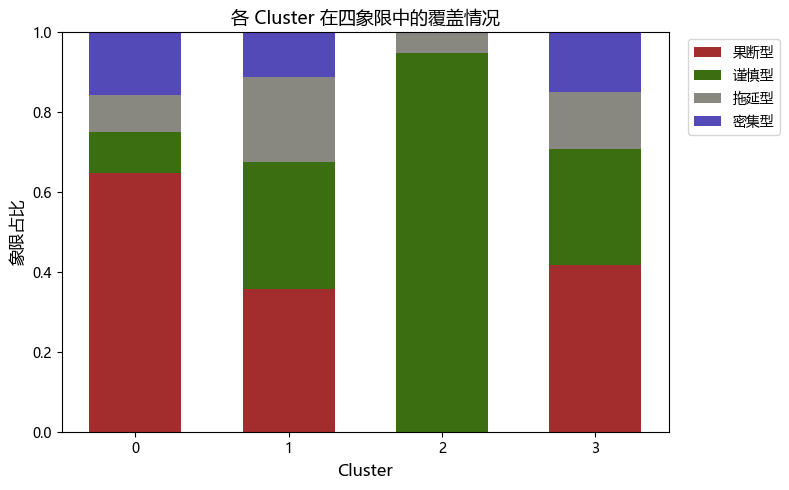

In [18]:
# 可视化：各 Cluster 在四象限中的覆盖情况（100% 堆叠柱状图）
# 每根柱子代表一个 cluster，柱内按比例堆叠该 cluster 落在四个象限里的占比，
# 直接呈现交叉表数字背后的模式：Cluster 2 几乎是单色（几乎全落在谨慎型），
# Cluster 1/3 则是四色混杂（说明四象限框架对这两个 cluster 没有区分度）
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
quadrant_colors = {'果断型': '#A32D2D', '谨慎型': '#3B6D11', '拖延型': '#888780', '密集型': '#534AB7'}
bottom = np.zeros(len(crosstab_pct))

for q in quadrant_order:
    ax.bar(crosstab_pct.index.astype(str), crosstab_pct[q], bottom=bottom,
           color=quadrant_colors[q], label=q, width=0.6)
    bottom += crosstab_pct[q].values

ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('象限占比', fontsize=12)
ax.set_title('各 Cluster 在四象限中的覆盖情况', fontsize=13)
ax.legend(fontsize=10, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 11. 聚类价格画像

In [ ]:
# price 已在第3节构造核心变量时合并进 data4，用作事后画像
print(data4.groupby('cluster')['price'].agg(['median', 'mean', 'count']))

# 保存 events5.csv作为最终数据集存档
data4.to_csv('events5.csv', index=False)
print(f"\nevents5.csv 已保存，{len(data4)} 行，{data4.shape[1]} 列")

          median           mean  count
cluster                               
0        59880.0  125306.910542   4259
1        45000.0  101734.870695   9234
2        48060.0  104865.729880   2162
3        52380.0  119443.991736   1452

events5.csv 已保存，18738 行，19 列


## 12. 决策树规则翻译

In [ ]:
# 目标变量是第9节 K-Means 的 cluster 标签——呼应无监督学习的结果，把聚类结果翻译成业务可读的判断规则。
# 并不是重新验证聚类是否有效（有效性已在第10节用 Kruskal-Wallis 检验确认）
# 用原始尺度变量（非 log）训练：规则里的数字才是业务能直接理解的阈值
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

tree_feat = ['decision_hours', 'research_views', 'total_purchases', 'active_days', 'has_addtocart']
X = data4[tree_feat]
y = data4['cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 比较几个深度："规则可用"意味着训练效果要足够好，"规则可读"意味着树不能过深；实现二者的平衡
print("=== 不同深度的准确率对比 ===")
for depth in [2, 3, 4, 5]:
    clf_d = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf_d.fit(X_train, y_train)
    print(f"max_depth={depth}: train_acc={clf_d.score(X_train, y_train):.3f}, "
          f"test_acc={clf_d.score(X_test, y_test):.3f}, 叶子数={clf_d.get_n_leaves()}")

# 选 max_depth=3：准确率已经有约91%，叶子数（7个）还在人能理解的范围
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)
print(f"\n最终选定 max_depth=3：train_acc={clf.score(X_train, y_train):.3f}, "
      f"test_acc={clf.score(X_test, y_test):.3f}")

persona = {0: '高经验决策(C0)', 1: '轻量决策(C1)', 2: '高摩擦决策(C2)', 3: '无加购决策(C3)'}
print("\n=== 决策规则 ===")
print(export_text(clf, feature_names=tree_feat, class_names=[persona[i] for i in sorted(persona)]))

print("=== 特征重要性 ===")
for f, imp in sorted(zip(tree_feat, clf.feature_importances_), key=lambda x: -x[1]):
    print(f"{f:20s} {imp:.3f}")

print("\n=== 混淆矩阵（测试集，行=真实cluster，列=预测cluster） ===")
print(confusion_matrix(y_test, clf.predict(X_test)))

=== 不同深度的准确率对比 ===
max_depth=2: train_acc=0.905, test_acc=0.893, 叶子数=4
max_depth=3: train_acc=0.919, test_acc=0.913, 叶子数=7
max_depth=4: train_acc=0.960, test_acc=0.954, 叶子数=13
max_depth=5: train_acc=0.975, test_acc=0.971, 叶子数=24

最终选定 max_depth=3：train_acc=0.919, test_acc=0.913

=== 决策规则 ===
|--- active_days <= 1.14
|   |--- has_addtocart <= 0.50
|   |   |--- class: 无加购决策(C3)
|   |--- has_addtocart >  0.50
|   |   |--- decision_hours <= 10.06
|   |   |   |--- class: 轻量决策(C1)
|   |   |--- decision_hours >  10.06
|   |   |   |--- class: 高摩擦决策(C2)
|--- active_days >  1.14
|   |--- decision_hours <= 7.25
|   |   |--- total_purchases <= 3.50
|   |   |   |--- class: 轻量决策(C1)
|   |   |--- total_purchases >  3.50
|   |   |   |--- class: 高经验决策(C0)
|   |--- decision_hours >  7.25
|   |   |--- has_addtocart <= 0.50
|   |   |   |--- class: 无加购决策(C3)
|   |   |--- has_addtocart >  0.50
|   |   |   |--- class: 高摩擦决策(C2)

=== 特征重要性 ===
active_days          0.451
decision_hours       0.266
has_addtocar

In [ ]:
# 规则翻译（业务视角）：
# 第一步先问"决策前活跃天数是否超过1.14天"，把"几乎是刚来的新访客"和"已经在平台待了一段时间的人"分开
# （这个变量单独的特征重要性最高 0.451，说明它一刀就能把四类决策大致分对一半以上）
#
# 新访客（活跃天数<=1.14天）：
#   先问"有没有加购"——在新访客里，没加购几乎就等于无加购决策(C3)，这一刀比直接问决策时长更干净
#   加购了的话，再用决策时长细分：10.06小时内搞定是轻量决策(C1)，拖过10小时是高摩擦决策(C2)
#
# 非新访客（活跃天数>1.14天）：
#   先看决策时长：7.25小时内搞定，再看决策前买过几次——超过3.5次是高经验决策(C0)，否则是轻量决策(C1)
#   拖过7.25小时：没加购是无加购决策(C3，比较少见但存在——老用户、纠结很久、最后没走购物车)，
#                 加购了是高摩擦决策(C2)
#
# 为什么"新访客"分支里先问"有没有加购"而不是先问决策时长：决策树的贪心机制代表它每一步只认"哪个变量+哪个阈值
# 眼下分得最干净"，不是按业务逻辑预设的顺序。在新访客这个子群体里，"有没有加购"恰好是一个几乎
# 完美的分类器（不加购几乎=C3，即无加购决策），比决策时长任何一个阈值都更干净，所以算法先选了它
#
# 为什么 research_views（回看次数）特征重要性是 0：这主要是技术原因，不是"回看次数不重要"的业务结论。
# decision_hours、active_days、has_addtocart 三个变量组合起来已经能把四类切得很干净（91.3%准确率），
# 不纯度已经降到很低；同时 research_views 和 decision_hours 本身中度相关（第8节相关矩阵 r=0.523），
# decision_hours 已经携带了 research_views 的大部分区分信息，决策树先用了 decision_hours 后，
# research_views 携带的基本是重复信息
# total_purchases 也只在一处起作用（重要性 0.050，区分 C0/C1 的那个 >3.5次 分支），权重很小
#
# 混淆矩阵通俗解读（行=真实cluster，列=规则猜出的cluster）：
# C0（高经验决策）1144个猜对，但201个被猜成C1——这部分高经验决策购买次数刚好卡在3.5次阈值附近，
#   没表现出典型的"经验丰富"特征，规则没认出来
# C1（轻量决策，最大群体）3002个猜对，准确率约97.6%，是四类里规则猜得最准的——这类决策各方面
#   都轻量，边界最清楚
# C2（高摩擦决策）606个猜对，但59个被猜成C1、27个被猜成C3、4个被猜成C0——是四类里规则最容易
#   猜错的，说明这个群体的简单规则边界不如其他三类干净
# C3（无加购决策）382个猜对，但50个被猜成C0、56个被猜成C1——大约1/5的无加购决策按这套简单规则看，
#   表现得跟普通购买决策差不多，是边界案例
# 整体准确率91.3%，说明这套"四步以内问完"的规则能复刻原聚类结果的九成以上

## 13. 子样本分析：浏览节奏与决策周期（research_views≥2）

In [ ]:
# 13.1 子样本构建：从 events3.csv 取 research_views>=2的记录
# 主分析（events4/events5）排除了 view_interval_mean，但限定到 research_views>=2 后，
# 每条记录至少有 1 个真实计算出的浏览间隔，重新获得分析意义，可单独分析"浏览节奏"与决策周期的关系
data3 = pd.read_csv("events3.csv", parse_dates=['first_trans'])
sub = data3[data3['research_views'] >= 2].copy()
print(f"子样本量：{len(sub)} 条（占主分析样本 {len(sub) / len(data3):.1%}）")

# 13.2 构造浏览规律性变量：view_interval_std / view_interval_cv（变异系数）
# 只看"平均间隔"还不足以刻画"浏览节奏"——也就是需要从原始浏览时间戳重新计算标准差，再算变异系数 
# CV = std / mean（无量纲，不受平均间隔尺度影响，可跨用户比较"规律 vs 不规律"）
ev2 = pd.read_csv("events2.csv", parse_dates=['timestamp'])
ev2_sub = ev2.merge(sub[['visitorid', 'itemid', 'first_trans']], on=['visitorid', 'itemid'], how='inner')
pre_views = ev2_sub[(ev2_sub['event'] == 'view') & (ev2_sub['timestamp'] < ev2_sub['first_trans'])] \
    .sort_values(['visitorid', 'itemid', 'timestamp'])

def interval_std(g):
    diffs = g['timestamp'].diff().dropna().dt.total_seconds() / 3600
    return diffs.std()

interval_std_df = pre_views.groupby(['visitorid', 'itemid']).apply(interval_std, include_groups=False) \
    .rename('view_interval_std').reset_index()
sub = sub.merge(interval_std_df, on=['visitorid', 'itemid'], how='left')
sub['view_interval_cv'] = np.where(sub['view_interval_mean'] > 0,
                                    sub['view_interval_std'] / sub['view_interval_mean'], np.nan)

# research_views==2 时只有 1 个间隔，标准差在数学上无法定义（std() 对单个值天然返回 NaN）——
# 与第三节 research_views==1 时 view_interval_mean 结构性设为 0 是同一类"结构性缺失"，
# 因此规律性分析需要进一步收窄到 research_views>=3 的子集，仅剩4445条记录
print(f"view_interval_cv 结构性缺失（仅 1 个间隔，research_views=2）：{sub['view_interval_cv'].isna().sum()} 条，"
      f"占比 {sub['view_interval_cv'].isna().mean():.1%}")

子样本量：8500 条（占主分析样本 45.4%）
view_interval_cv 结构性缺失（仅 1 个间隔，research_views=2）：4445 条，占比 52.3%


In [ ]:
# 13.3 描述性统计 + 变量变换
print("=== view_interval_mean（浏览节奏：相邻浏览平均间隔，小时） ===")
print(sub['view_interval_mean'].describe())
print(f"偏态：{sub['view_interval_mean'].skew():.3f}")

print(f"\n=== view_interval_cv（浏览规律性：变异系数，n={sub['view_interval_cv'].notna().sum()}） ===")
print(sub['view_interval_cv'].describe())
print(f"偏态：{sub['view_interval_cv'].skew():.3f}")

# view_interval_mean 偏态明显（>1），log1p 变换；CV 是比值，偏态温和，不做变换
sub['log_view_interval_mean'] = np.log1p(sub['view_interval_mean'])
sub['log_decision_hours'] = np.log1p(sub['decision_hours'])
sub['log_research_views'] = np.log1p(sub['research_views'])

=== view_interval_mean（浏览节奏：相邻浏览平均间隔，小时） ===
count    8500.000000
mean       23.030903
std       106.010656
min         0.000013
25%         0.039224
50%         0.146735
75%         2.930623
max      2112.175531
Name: view_interval_mean, dtype: float64
偏态：10.100

=== view_interval_cv（浏览规律性：变异系数，n=4055） ===
count    4055.000000
mean        1.186320
std         0.591141
min         0.001257
25%         0.786058
50%         1.223244
75%         1.475939
max         6.937427
Name: view_interval_cv, dtype: float64
偏态：0.545


In [ ]:
# 13.4 浏览节奏（平均间隔）与决策周期：相关系数很高，但需要警惕构造性重叠
print("=== 相关系数：view_interval_mean vs decision_hours ===")
print(f"原始值：r = {sub['view_interval_mean'].corr(sub['decision_hours']):.3f}")
print(f"log-log：r = {sub['log_view_interval_mean'].corr(sub['log_decision_hours']):.3f}")

# 注意：共线性对应的重复问题
# 这个高相关系数仅反映了"决策周期=浏览间隔×(回看次数-1)"这一恒等的数学关系，并未产生额外信息
# 控制 research_views 后看 R^2 是否依然高到不正常（如果是，说明确实是恒等式级别的重叠）：
X_pace = sm.add_constant(sub[['log_view_interval_mean', 'log_research_views']])
ols_pace = sm.OLS(sub['log_decision_hours'], X_pace).fit()
print(ols_pace.summary())

=== 相关系数：view_interval_mean vs decision_hours ===
原始值：r = 0.788
log-log：r = 0.943
                            OLS Regression Results                            
Dep. Variable:     log_decision_hours   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 5.530e+04
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:00:34   Log-Likelihood:                -6254.4
No. Observations:                8500   AIC:                         1.251e+04
Df Residuals:                    8497   BIC:                         1.254e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [ ]:
# 13.5 浏览规律性（CV）与决策周期：research_views>=3
from scipy.stats import spearmanr, kruskal

sub_reg = sub.dropna(subset=['view_interval_cv']).copy()
print(f"规律性分析子集：n={len(sub_reg)}")

print("\n=== 相关系数：view_interval_cv vs decision_hours ===")
print(f"原始值：r = {sub_reg['view_interval_cv'].corr(sub_reg['decision_hours']):.3f}")
print(f"vs log_decision_hours：r = {sub_reg['view_interval_cv'].corr(sub_reg['log_decision_hours']):.3f}")
rho, p_rho = spearmanr(sub_reg['view_interval_cv'], sub_reg['decision_hours'])
print(f"Spearman 等级相关（不依赖线性假设，稳健性验证）：rho = {rho:.3f}, p = {p_rho:.4g}")

# CV 与 view_interval_mean 几乎不相关，说明"规律性"是独立于"节奏快慢"的另一个维度，
print(f"\nCV 与 view_interval_mean 的相关系数：{sub_reg['view_interval_cv'].corr(sub_reg['view_interval_mean']):.3f}")

# 按中位数分组：规律型（低CV）vs 不规律型（高CV）
median_cv = sub_reg['view_interval_cv'].median()
sub_reg['regularity_group'] = np.where(sub_reg['view_interval_cv'] <= median_cv, '规律型(低CV)', '不规律型(高CV)')

print("\n=== 两组决策周期对比 ===")
print(sub_reg.groupby('regularity_group')['decision_hours'].agg(['median', 'mean', 'count']))

stat, p = kruskal(sub_reg.loc[sub_reg['regularity_group'] == '规律型(低CV)', 'decision_hours'],
                   sub_reg.loc[sub_reg['regularity_group'] == '不规律型(高CV)', 'decision_hours'])
print(f"\nKruskal-Wallis：H={stat:.2f}, p={p:.4g}（显著：{p < 0.05}）")

# 控制 research_views 后，CV 对决策周期的净效应（R^2 远低于 13.4 节，说明不是恒等式关系）
X_reg = sm.add_constant(sub_reg[['view_interval_cv', 'log_research_views']])
ols_reg = sm.OLS(sub_reg['log_decision_hours'], X_reg).fit()
print(ols_reg.summary())

规律性分析子集：n=4055

=== 相关系数：view_interval_cv vs decision_hours ===
原始值：r = 0.216
vs log_decision_hours：r = 0.508
Spearman 等级相关（不依赖线性假设，稳健性验证）：rho = 0.611, p = 0

CV 与 view_interval_mean 的相关系数：0.111

=== 两组决策周期对比 ===
                     median        mean  count
regularity_group                              
不规律型(高CV)         21.363078  123.266530   2027
规律型(低CV)           0.433737   30.852673   2028

Kruskal-Wallis：H=1285.17, p=1.885e-281（显著：True）
                            OLS Regression Results                            
Dep. Variable:     log_decision_hours   R-squared:                       0.265
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     729.7
Date:                Wed, 24 Jun 2026   Prob (F-statistic):          2.27e-271
Time:                        18:00:34   Log-Likelihood:                -8064.6
No. Observations:                4055   AIC:                         1.614e+

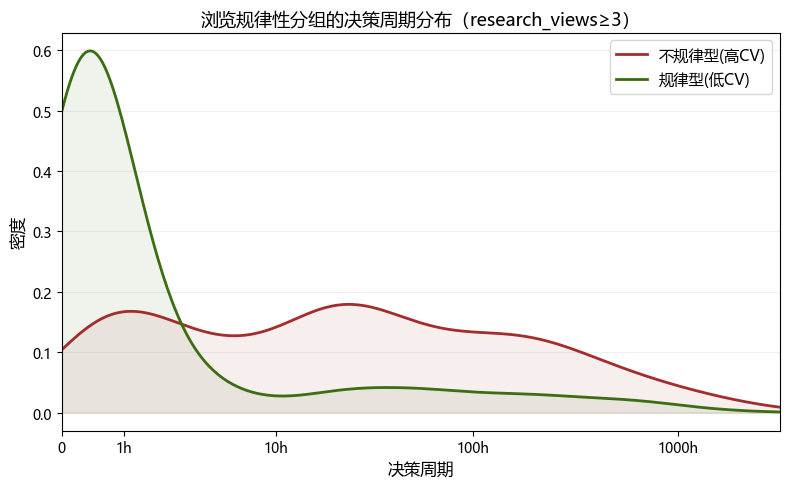

In [ ]:
# 13.6 可视化：规律型 vs 不规律型 的决策周期分布对比（log 刻度还原为原始小时数）
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(8, 5))
colors_reg = {'规律型(低CV)': '#3B6D11', '不规律型(高CV)': '#A32D2D'}
xs = np.linspace(0, sub_reg['log_decision_hours'].max(), 300)

for grp_name, grp in sub_reg.groupby('regularity_group'):
    kde = gaussian_kde(grp['log_decision_hours'], bw_method=0.3)
    ax.plot(xs, kde(xs), color=colors_reg[grp_name], linewidth=2, label=grp_name)
    ax.fill_between(xs, kde(xs), alpha=0.08, color=colors_reg[grp_name])

tick_vals = [0, np.log1p(1), np.log1p(10), np.log1p(100), np.log1p(1000)]
tick_labels = ['0', '1h', '10h', '100h', '1000h']
ax.set_xticks(tick_vals)
ax.set_xticklabels(tick_labels)
ax.set_xlim(0, sub_reg['log_decision_hours'].max())

ax.set_xlabel('决策周期', fontsize=12)
ax.set_ylabel('密度', fontsize=12)
ax.set_title('浏览规律性分组的决策周期分布（research_views≥3）', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# 13.7 小结
# 浏览节奏（view_interval_mean）与决策周期高度相关（log-log r=0.943，OLS R^2=0.929），
# 不是独立的行为发现，仅作为构造 CV 的中间变量保留
#
# 浏览规律性（view_interval_cv）是更真实的独立信号：CV 与 view_interval_mean 几乎不相关（r=0.111），
# 规律型用户决策周期中位数仅0.43h，不规律型用户中位数达21.4h，
# 相差近50倍，Kruskal-Wallis 检验极显著（H=1285.17，p<0.001）
#
# 业务解读：检索次数相近、平均间隔也相近的两个用户，如果浏览节奏是连续集中的（规律型），
# 通常当场或当天就完成购买；如果浏览之间夹杂长时间断点（不规律型，比如先看一次、隔几天再回来看），
# 决策周期会被大幅拉长。这种"断点式回访"可能反映用户在浏览间隔期经历了犹豫、对比站外信息、
# 或购买意图被打断后需要重新唤起——呼应第十二节辅助假设二（对应高摩擦决策）对"谨慎型"用户摩擦根源的诊断，
# 浏览节奏的不规律性可以作为识别"仍在犹豫、需要被重新唤起"用户的候选行为信号，
# 比单纯的检索次数（research_views）更精细，可用于设计召回类干预的触发时机
#
# 局限：仅覆盖 research_views>=2（45.4%样本），CV进一步要求research_views>=3（21.6%样本），
# 样本量缩小、统计功效降低；分析仍是事后关联，不构成因果证据